In [15]:
#importing
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



Matplotlib is building the font cache; this may take a moment.


In [10]:
train_df=pd.read_csv('train_ctrUa4K.csv')
train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [11]:
train_df.shape

(614, 13)

In [12]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [14]:
null_counts=train_df.isnull().sum()
print(null_counts)

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

null_counts=train_df.isnull().sum()
missing_data=null_counts[null_counts>0]

Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64


/var/folders/0y/b4hmkd6x5hzg25wqny0hdd400000gn/T/ipykernel_55430/2908207928.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.index, y=missing_data.values , palette="viridis")


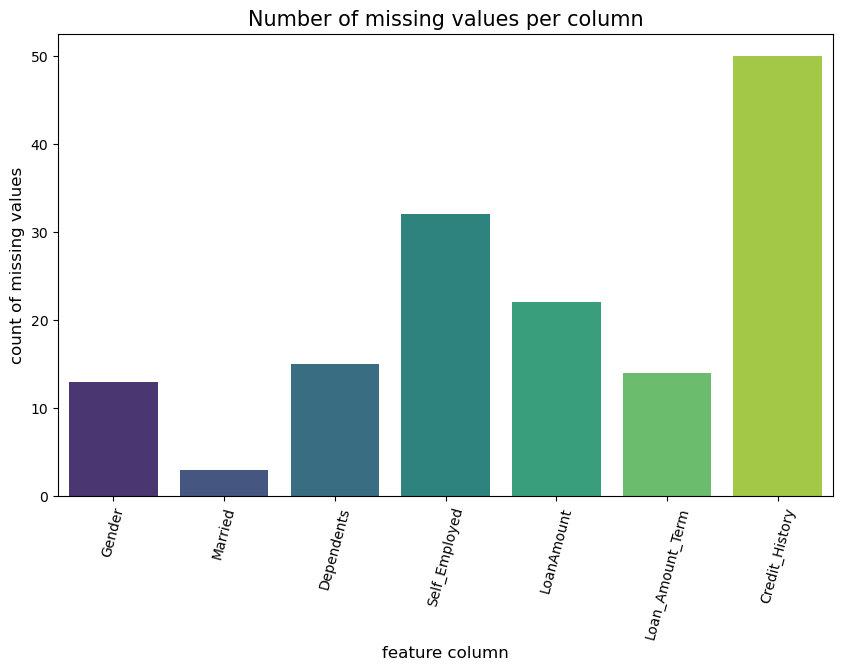

In [23]:
print(missing_data)
plt.figure(figsize=(10,6))
sns.barplot(x=missing_data.index, y=missing_data.values , palette="viridis")
plt.title("Number of missing values per column" , fontsize=15)
plt.xlabel('feature column', fontsize=12)
plt.ylabel('count of missing values', fontsize=12)
plt.xticks(rotation=75)
plt.show()

In [18]:
#set the size of fig
plt.figure(figsize=(10,6))


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [24]:
# find columns that actually have missing values:

cols_with_missing=train_df.columns[train_df.isnull().any()].tolist()

In [25]:
print(cols_with_missing)

['Gender', 'Married', 'Dependents', 'Self_Employed', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


Index(['LoanAmount', 'Loan_Amount_Term', 'Credit_History'], dtype='object')
Index(['Gender', 'Married', 'Dependents', 'Self_Employed'], dtype='object')


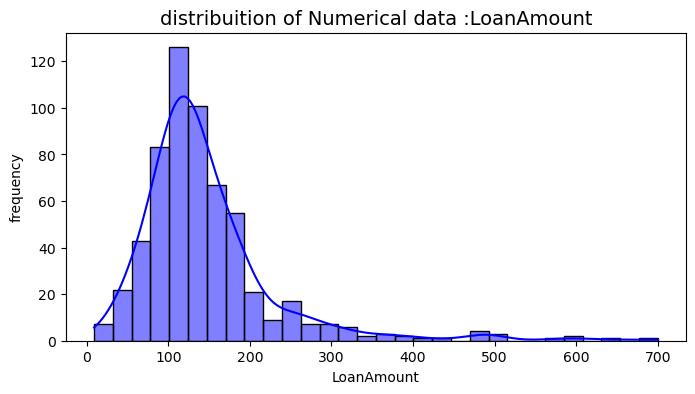

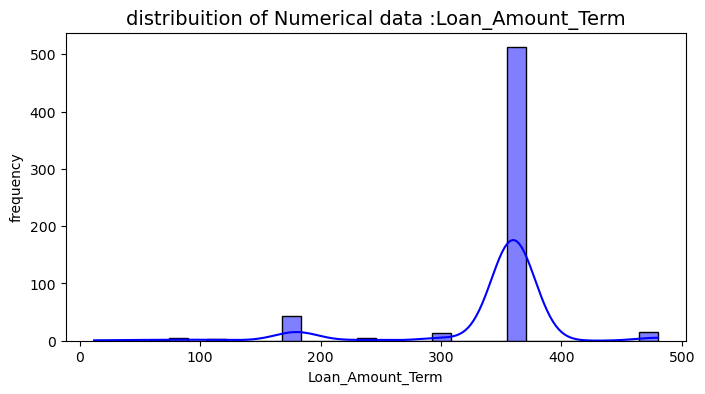

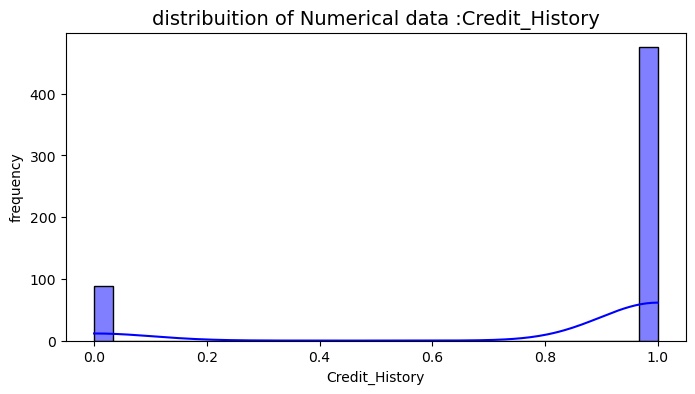

Index(['Gender', 'Married', 'Dependents', 'Self_Employed'], dtype='object')

In [31]:
# 2. Separate them into numerical and categorical columns

num_cols=train_df[cols_with_missing].select_dtypes(include=['int64', 'float64']).columns
cat_cols=train_df[cols_with_missing].select_dtypes(include=['object']).columns
print(num_cols)
print(cat_cols)


#plot numerical columns.

#num_cols
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(train_df[col].dropna(), kde=True,color='blue',bins=30)
    plt.title(f'distribuition of Numerical data :{col}',fontsize=14)
    plt.xlabel(col)
    plt.ylabel('frequency')
    plt.show()



cat_cols


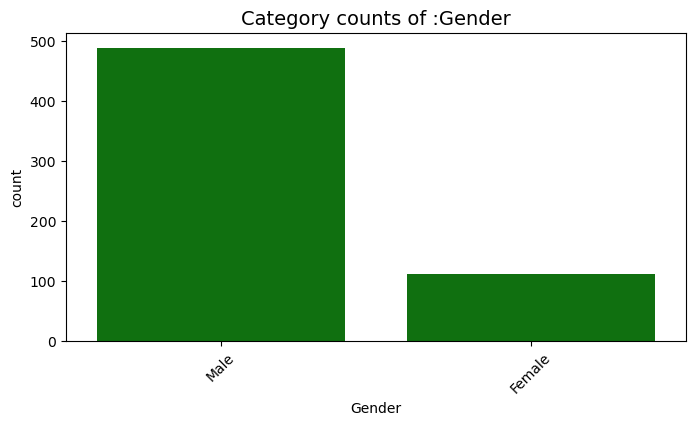

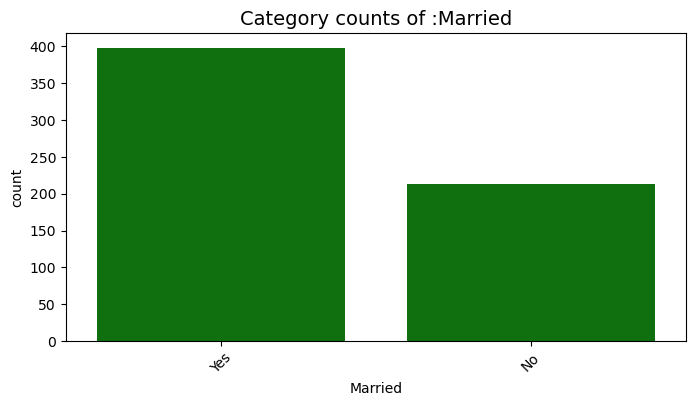

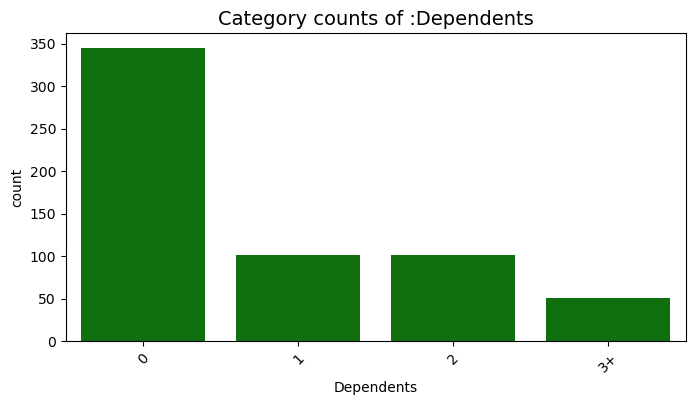

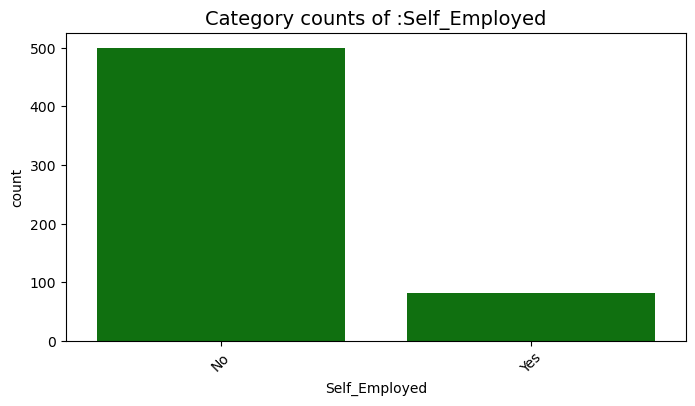

In [33]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=train_df, x=col, order=train_df[col].value_counts().index, color='green')
    plt.title(f'Category counts of :{col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('count')
    plt.xticks(rotation=45)
    plt.show()

In [34]:
train_df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [39]:
train_df['LoanAmount']

0        NaN
1      128.0
2       66.0
3      120.0
4      141.0
       ...  
609     71.0
610     40.0
611    253.0
612    187.0
613    133.0
Name: LoanAmount, Length: 614, dtype: float64

In [41]:
column_name='LoanAmount'


# 2. Calculate and print the median so you know what value is being used
median_value=train_df[column_name].median()
print(f"the median value of {column_name} is {median_value}")

the median value of LoanAmount is 128.0


In [43]:
train_df[column_name]=train_df[column_name].fillna(median_value)

remaining_missing=train_df[column_name].isnull().sum()
print(f'missing values in a {column_name}:{remaining_missing}')

missing values in a LoanAmount:0
